In this notebook, we compare at large overparametrization (i.e in the kernel limit) the true variance $\Delta$ and the ensemble variance with the Bayes-optimal variance. 
Then, we look at what's the optimal way to parametrize the scaling of the variance to match the true variance by using a validation set.

**NOTE** : We can also get from our overparametrized paper the variance `v` for the Pseudo-Baye, and we can do a bias variance decomposition

In [1]:
using BootstrapAsymptotics
using Plots
using ProgressBars

In [2]:
# for the erf activation
κ1    =  2.0 / sqrt(3* pi)
κstar = 0.200364

0.200364

In [65]:
δ = 5.0
λ = 1.0

# I think we can take Δ_add = 0.0 asymptotically 
kernel_problem = BootstrapAsymptotics.KernelRidgeOverparametrized(
    δ = δ,
    Δ = 1.0,
    ρ = 1.0,
    κ1 = κ1,
    κstar = κstar,
    λ = λ
)

kernel_result = BootstrapAsymptotics.state_evolution(
    kernel_problem,
    FullResampling(),
    FullResampling();
    rtol=1e-4,
    max_iteration=100,
    show_progress=false,
)

###

student_over_teacher_dim = 1000.0

ridge_problem = BootstrapAsymptotics.build_ridge_overparametrized(
    α = δ / student_over_teacher_dim,
    true_Δ = 1.0,
    λ = λ,
    true_ρ = 1.0,
    κ1 = κ1,
    κstar = κstar,
    student_over_teacher_dim = student_over_teacher_dim
)

ridge_result = BootstrapAsymptotics.state_evolution(
    ridge_problem,
    FullResampling(),
    FullResampling();
    rtol=1e-4,
    max_iteration=100,
    show_progress=false,
)

println("$(kernel_result.overlaps.Q), $(ridge_result.overlaps.Q)")

[0.47963389544032753 0.3843147461628896; 0.3843147461628896 0.47963389544032753], [0.5105557318253985 0.40960009726249674; 0.40960009726249674 0.5105557318253985]


---

In [3]:
function get_variances(sample_over_teacher::Real, Δ::Real, κ1::Real, κstar::Real, λ::Real; algos, use_kernel::Bool)::Dict
    dict_return = Dict()

    # take large value (but not too large for numerical precision)
    student_over_teacher_dim = 1000.0

    for algo in algos
        if use_kernel == false
            problem = BootstrapAsymptotics.build_ridge_overparametrized(
                α                        = sample_over_teacher / student_over_teacher_dim,
                true_Δ                   = Δ,
                λ                        = λ, 
                true_ρ                    = 1.0,
                κ1                       = κ1,
                κstar                    = κstar,
                student_over_teacher_dim = student_over_teacher_dim
            )

            result = BootstrapAsymptotics.state_evolution(
                problem,
                algo,
                algo;
                rtol=1e-4,
                max_iteration=100,
                show_progress=false,
            )
            dict_return[algo] = result
        else
            problem = BootstrapAsymptotics.KernelRidgeOverparametrized(
                δ = sample_over_teacher,
                Δ = Δ,
                ρ = 1.0,
                κ1 = κ1,
                κstar = κstar,
                λ = λ
            )
            
            result = BootstrapAsymptotics.state_evolution(
                problem,
                algo,
                algo;
                rtol=1e-4,
                max_iteration=100,
                show_progress=false,
            )
            dict_return[algo] = result
            end
        end

    return dict_return
end

get_variances (generic function with 1 method)

---

Below we plot the variance when we change the number of samples over teacher dimension in the kernel regime

In [4]:
# sample_over_teacher_range = 0.5:0.5:5.0
sample_over_teacher_range = 10 .^ range(0.0, stop=4, length=100)

algos = [
    Subsampling(r = 0.5),
    PairBootstrap(p_max = 5)
]

Δ = 1.0
λ = 1e-4

variances = Dict([
    algo => [] for algo in algos
])

for sample_over_teacher in ProgressBar(sample_over_teacher_range)
    result = get_variances(
        sample_over_teacher,
        Δ,
        κ1,
        κstar,
        λ;
        algos = algos,
        use_kernel = true
    )

    for algo in algos
        push!(variances[algo], result[algo].overlaps.Q[1, 1] - result[algo].overlaps.Q[1, 2])
    end

end

0.0%┣                                             ┫ 0/100 [00:01<-2:-10, -1s/it]
1.0%┣▍                                         ┫ 1/100 [00:03<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 100/100 [00:03<00:00, 29it/s]
100.0%┣██████████████████████████████████████████┫ 100/100 [00:03<00:00, 29it/s]


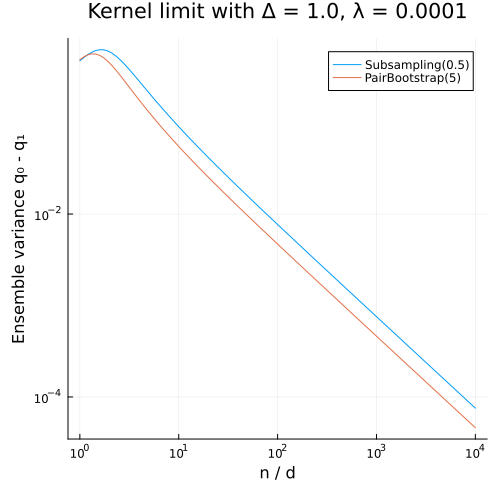

"/Users/clarte/Code/Uncertainty/Bootstrap/BootstrapAsymptotics/experiments/plots/random_features/variance_kernel_limit_Δ_1.0_λ_0.0001.png"

In [78]:

plot(xlabel="n / d", ylabel="Ensemble variance q₀ - q₁", xscale=:log10, yscale=:log10, size=(500, 500))

for algo in algos
    plot!(sample_over_teacher_range, variances[algo], label="$algo")
end

display(plot!(legend=true, title="Kernel limit with Δ = $Δ, λ = $λ"))
# save the figure
savefig("plots/random_features/variance_kernel_limit_Δ_$(Δ)_λ_$(λ).png")

---

Below we run at fixed n / d but change the intrinsic noise 

In [ ]:
Δ_range = 10 .^ range(-2.0, stop=4.0, length=100)
λ = 1e-4
sample_over_teacher = 2.0

variances = Dict([
    algo => [] for algo in algos
])

for Δ in Δ_range
    result = get_variances(
        sample_over_teacher,
        Δ,
        κ1,
        κstar,
        λ;
        algos = algos,
        use_kernel = true
    )

    for algo in algos
        push!(variances[algo], result[algo].overlaps.Q[1, 1] - result[algo].overlaps.Q[1, 2])
    end
end

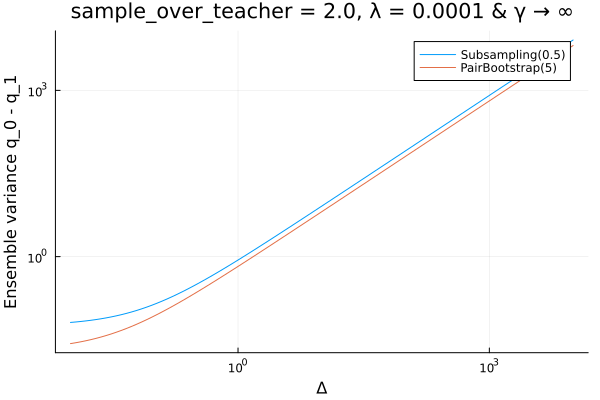

In [54]:
# Numerical observation : the variance in the kernel regime scales linearly with the true variance Δ

plot(xlabel="Δ", ylabel="Ensemble variance q_0 - q_1", xscale=:log10, yscale=:log10)

for algo in algos
    plot!(Δ_range, variances[algo], label="$algo")
end

display(plot!(legend=true, title="sample_over_teacher = $sample_over_teacher, λ = $λ & γ → ∞"))